In [1]:
import pandas as pd 
import numpy as np
import joblib
import time
import sklearn.metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    confusion_matrix,
    roc_auc_score
)
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier

## Load dataset generated by CovaS

In [2]:
def calculate_macro_tpr_fpr(voting_cm):
    num_classes = voting_cm.shape[0]
    tpr_list = []
    fpr_list = []

    for i in range(num_classes):
        TP = voting_cm[i, i]
        FN = np.sum(voting_cm[i, :]) - TP
        FP = np.sum(voting_cm[:, i]) - TP
        TN = np.sum(voting_cm) - (TP + FN + FP)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    macro_tpr = np.mean(tpr_list)
    macro_fpr = np.mean(fpr_list)

    return macro_tpr, macro_fpr

train = pd.read_csv('./DS/train_shap_66.csv')
test = pd.read_csv('./DS/test_shap_66.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']
X_test = test.drop(['Label'], axis=1)
y_test = test['Label']
y_test = pd.Series(y_test)
y_train = pd.Series(y_train)

## XGBoost

In [3]:
xgb_params = {
    'tree_method': 'gpu_hist',         
    'predictor': 'gpu_predictor',      
    'max_depth': 15,
    'n_estimators': 5000,
    'learning_rate': 0.6, 
    'eval_metric': 'auc',
    'use_label_encoder': False,
    'objective':"multi:softmax", 
    'num_class':len(y_train.unique()),
    'booster': 'gbtree',
    'random_state': 42
}


print("XGBClassifier Starting")
xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=30,
    verbose=False
)
xgb_start_time = time.time()
xgb_prediction = xgb_model.predict(X_test)
xgb_end_time = time.time()
xgb_time = xgb_end_time - xgb_start_time
print("XGBClassifier Finished")

xgb_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=xgb_prediction)
xgb_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=xgb_prediction, average='macro')
xgb_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=xgb_prediction, average='macro')
xgb_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=xgb_prediction, average='macro')
xgb_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=xgb_prediction)
xgb_fp = xgb_cm[0, 1]
print("XGBoost report:")
print("XGBoost Time:", xgb_time)
print("XGBoost Accuracy:", xgb_acc)
print("XGBoost Precision:", xgb_precision)
print("XGBoost F1:", xgb_f1)
print("XGBoost Recall:", xgb_recall)
print("XGBoost FP", xgb_fp)
print("XGBoost CM:", xgb_cm)
xgb_tpr, xgb_fpr = calculate_macro_tpr_fpr(xgb_cm)
print(f'XGBoost Macro-average TPR: {xgb_tpr}')
print(f'XGBoost Macro-average FPR: {xgb_fpr}')

XGBClassifier Starting
XGBClassifier Finished
XGBoost report:
XGBoost Time: 0.11185741424560547
XGBoost Accuracy: 0.8525641025641025
XGBoost Precision: 0.8487168566676037
XGBoost F1: 0.8476601943839882
XGBoost Recall: 0.8525641025641026
XGBoost FP 0
XGBoost CM: [[167   0   0   0   2   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   0 169   0   0   0   0   0   0   0   0   0]
 [  0   0   0 169   0   0   0   0   0   0   0   0]
 [  0   0   0   0 169   0   0   0   0   0   0   0]
 [  0   0   0   0   0 169   0   0   0   0   0   0]
 [  0   0   0   0   0   0 169   0   0   0   0   0]
 [  0   1  38   1   0   0   0  69  36   6  18   0]
 [  0   0   0   0   0   0   0  44 125   0   0   0]
 [  0   0   9   0   0   0   0   6   0 106  48   0]
 [  0   0   0   0   0   0   0   0   0  89  80   0]
 [  0   0   0   0   0   0   1   0   0   0   0 168]]
XGBoost Macro-average TPR: 0.8525641025641026
XGBoost Macro-average FPR: 0.013403263403263402


In [20]:
joblib.dump(xgb_model, './models/framework_xgb_best_llm.pkl')

['./models/framework_xgb_best.pkl']

## ExtraTree

In [4]:
et_params = {
    "n_estimators": 60,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": True,
    "criterion": "entropy"
}

print("ExtraTreesClassifier Starting")
et_model = ExtraTreesClassifier(**et_params)
et_model.fit(X=X_train, y=y_train)
et_start_time = time.time()
et_prediction = et_model.predict(X_test)
et_end_time = time.time()
et_time = et_end_time - et_start_time
print("ExtraTreesClassifier Finished")

et_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=et_prediction)
et_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=et_prediction, average='macro')
et_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=et_prediction, average='macro')
et_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=et_prediction, average='macro')
et_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=et_prediction)
et_fp = et_cm[0, 1]
print("ExtraTrees report:")
print("ExtraTrees Time:", et_end_time - et_start_time)
print("ExtraTrees Accuracy:", et_acc)
print("ExtraTrees Precision:", et_precision)
print("ExtraTrees F1:", et_f1)
print("ExtraTrees Recall:", et_recall)
print("ExtraTrees FP:", et_fp)
print("ExtraTrees CM:\n", et_cm)
et_tpr, et_fpr = calculate_macro_tpr_fpr(et_cm)
print(f'ExtraTrees Macro-average TPR: {et_tpr}')
print(f'ExtraTrees Macro-average FPR: {et_fpr}')

ExtraTreesClassifier Starting
ExtraTreesClassifier Finished
ExtraTrees report:
ExtraTrees Time: 0.11594939231872559
ExtraTrees Accuracy: 0.8555226824457594
ExtraTrees Precision: 0.8536535021067801
ExtraTrees F1: 0.851829172475585
ExtraTrees Recall: 0.8555226824457595
ExtraTrees FP: 0
ExtraTrees CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   0 169   0   0   0   0   0   0   0   0   0]
 [  0   0   0 169   0   0   0   0   0   0   0   0]
 [  0   0   0   0 169   0   0   0   0   0   0   0]
 [  0   0   0   0   0 169   0   0   0   0   0   0]
 [  0   0   0   0   0   0 169   0   0   0   0   0]
 [  0   1  27   0   0   0   0  82  34  10  15   0]
 [  0   0   0   0   0   0   0  37 132   0   0   0]
 [  0   0  11   0   0   0   0   5   0 100  53   0]
 [  0   0   0   0   0   0   0   1   0  99  69   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]
ExtraTrees Macro-average TPR: 0.8555226824457595
ExtraTrees Macro-average FPR: 0.01313

## RandomForest

In [5]:
rf_params = {
    "n_estimators": 200,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": True,
    "criterion": "entropy"
}

print("RandomForestClassifier Starting")
rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X=X_train, y=y_train)
rf_start_time = time.time()
rf_prediction = rf_model.predict(X_test)
rf_end_time = time.time()
rf_time = rf_end_time - rf_start_time
print("RandomForestClassifier Finished")

rf_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=rf_prediction)
rf_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=rf_prediction, average='macro')
rf_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=rf_prediction, average='macro')
rf_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=rf_prediction, average='macro')
rf_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=rf_prediction)
rf_fp = rf_cm[0, 1]
print("RandomForest report:")
print("RandomForest Time:", rf_end_time - rf_start_time)
print("RandomForest Accuracy:", rf_acc)
print("RandomForest Precision:", rf_precision)
print("RandomForest F1:", rf_f1)
print("RandomForest Recall:", rf_recall)
print("RandomForest FP:", rf_fp)
print("RandomForest CM:", rf_cm)
rf_tpr, rf_fpr = calculate_macro_tpr_fpr(rf_cm)
print(f'RandomForest Macro-average TPR: {rf_tpr}')
print(f'RandomForest Macro-average FPR: {rf_fpr}')

RandomForestClassifier Starting
RandomForestClassifier Finished
RandomForest report:
RandomForest Time: 0.12318825721740723
RandomForest Accuracy: 0.854043392504931
RandomForest Precision: 0.8521349460593205
RandomForest F1: 0.8493029664497582
RandomForest Recall: 0.854043392504931
RandomForest FP: 0
RandomForest CM: [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   0 169   0   0   0   0   0   0   0   0   0]
 [  0   0   0 169   0   0   0   0   0   0   0   0]
 [  0   0   0   0 169   0   0   0   0   0   0   0]
 [  0   0   0   0   1 168   0   0   0   0   0   0]
 [  0   0   0   0   0   0 169   0   0   0   0   0]
 [  0   1  35   1   1   0   2  78  28  10  13   0]
 [  0   0   0   0   0   0   0  44 125   0   0   0]
 [  0   0  12   0   0   0   0   5   0 109  43   0]
 [  0   0   0   0   0   0   0   1   0  99  69   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]
RandomForest Macro-average TPR: 0.854043392504931
RandomForest Macro

In [1]:
from lightgbm import LGBMClassifier, early_stopping

lgbm_params = {
    "learning_rate": 0.099,
    "n_estimators": 5000,
    "device": "cpu",
    "verbosity": -1,
    "random_state": 42,
    "n_jobs": -1,
    "boosting_type": "gbdt",
    "objective": "multiclass",
    "metric": "multi_logloss",
    "num_class": None,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "feature_fraction": 0.8,
    "min_child_samples": 20 
}

# Train LightGBM Model
print("LightGBM Starting")
lgbm_model = LGBMClassifier(**lgbm_params)
lgbm_model.fit(
    X=X_train, y=y_train, 
    eval_set=[(X_test, y_test)],
    callbacks=[early_stopping(stopping_rounds=300)],
)
lgbm_prediction = lgbm_model.predict(X_test)
print("LightGBM Finished")

lgbm_acc = sklearn.metrics.accuracy_score(y_test, lgbm_prediction)
lgbm_precision = sklearn.metrics.precision_score(y_test, lgbm_prediction, average='macro')
lgbm_f1 = sklearn.metrics.f1_score(y_test, lgbm_prediction, average='macro')
lgbm_recall = sklearn.metrics.recall_score(y_test, lgbm_prediction, average='macro')
lgbm_cm = sklearn.metrics.confusion_matrix(y_test, lgbm_prediction)

lgbm_probs = lgbm_model.predict_proba(X_test)
lgbm_auc = roc_auc_score(y_test, lgbm_probs, multi_class='ovr', average='macro')

print("LightGBM report:")
print("LightGBM Accuracy:", lgbm_acc)
print("LightGBM Precision:", lgbm_precision)
print("LightGBM F1:", lgbm_f1)
print("LightGBM Recall:", lgbm_recall)
print("LightGBM ROC AUC:", lgbm_auc)
print("LightGBM CM:\n", lgbm_cm)
lgbm_tpr, lgbm_fpr = calculate_macro_tpr_fpr(lgbm_cm)
print(f'LightGBM TPR: {lgbm_tpr}')
print(f'LightGBM FPR: {lgbm_fpr}')

LightGBM Starting
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[41]	valid_0's multi_logloss: 0.461563
LightGBM Finished
LightGBM report:
LightGBM Accuracy: 0.8451676528599605
LightGBM Precision: 0.8413853631831524
LightGBM F1: 0.8405602047429012
LightGBM Recall: 0.8451676528599606
LightGBM ROC AUC: 0.9859346767630791
LightGBM CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   0 167   0   0   0   0   1   0   1   0   0]
 [  0   0   0 168   0   0   1   0   0   0   0   0]
 [  0   0   0   1 168   0   0   0   0   0   0   0]
 [  0   0   0   0   0 169   0   0   0   0   0   0]
 [  0   0   0   1   1   0 167   0   0   0   0   0]
 [  0   1  41   0   0   0   2  71  36   8  10   0]
 [  0   0   0   0   0   0   0  46 123   0   0   0]
 [  0   0  10   0   1   0   0   

In [3]:
joblib.dump(lgbm_model, './models/framework_lgbm_best.pkl')

['./models/framework_lgbm_best.pkl']


In [5]:
from catboost import CatBoostClassifier
import time, sklearn

cat_params = {
    "iterations": 5000,
    "depth": 15,
    "learning_rate": 0.7,
    "loss_function": "MultiClass",
    "task_type": "GPU",
    "random_seed": 42,
    "eval_metric": "TotalF1",      # macro F1 cho đa lớp
    "od_type": "Iter",             # early stopping kiểu số vòng
    "od_wait": 30,                 # tương đương early_stopping_rounds=30
    "classes_count": len(y_train.unique())
}

print("CatBoost Starting")
cat_model = CatBoostClassifier(**cat_params)

# fit model
cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=False
)

cat_start_time = time.time()
cat_prediction = cat_model.predict(X_test)
cat_end_time = time.time()
cat_time = cat_end_time - cat_start_time
print("CatBoost Finished")

cat_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=cat_prediction)
cat_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=cat_prediction, average="macro")
cat_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=cat_prediction, average="macro")
cat_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=cat_prediction, average="macro")
cat_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=cat_prediction)
cat_fp = cat_cm[0, 1] if cat_cm.shape[0] > 1 else 0

print("CatBoost report:")
print("CatBoost Time:", cat_time)
print("CatBoost Accuracy:", cat_acc)
print("CatBoost Precision:", cat_precision)
print("CatBoost F1:", cat_f1)
print("CatBoost Recall:", cat_recall)
print("CatBoost FP", cat_fp)
print("CatBoost CM:", cat_cm)

cat_tpr, cat_fpr = calculate_macro_tpr_fpr(cat_cm)
print(f"CatBoost Macro-average TPR: {cat_tpr}")
print(f"CatBoost Macro-average FPR: {cat_fpr}")

CatBoost Starting
CatBoost Finished
CatBoost report:
CatBoost Time: 0.011227846145629883
CatBoost Accuracy: 0.8357988165680473
CatBoost Precision: 0.8262457754029325
CatBoost F1: 0.827278169145663
CatBoost Recall: 0.8357988165680474
CatBoost FP 0
CatBoost CM: [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   0 169   0   0   0   0   0   0   0   0   0]
 [  0   0   0 169   0   0   0   0   0   0   0   0]
 [  0   0   0   1 168   0   0   0   0   0   0   0]
 [  0   0   0   1   0 166   0   0   1   0   1   0]
 [  0   0   0   0   0   0 169   0   0   0   0   0]
 [  2   1  32   5  11   0   7  71  22   5  13   0]
 [  0   0   0   2   0   0   0  41 126   0   0   0]
 [  0   1  11   5   4   0   8   5   0  84  51   0]
 [  0   1   2   0   0   1   0   1   0  98  66   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]
CatBoost Macro-average TPR: 0.8357988165680474
CatBoost Macro-average FPR: 0.014927380311995697


In [6]:
joblib.dump(cat_model, './models/framework_cat_best.pkl')

['./models/framework_cat_best.pkl']

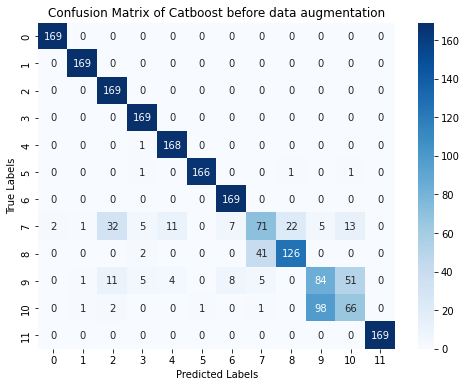

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
cat_model = CatBoostClassifier()
cat_model = joblib.load('./models/framework_cat_best.pkl')
cat_prediction = cat_model.predict(X_test)
cat_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=cat_prediction)
plt.figure(figsize=(8, 6))
sns.heatmap(cat_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of Catboost before data augmentation')
plt.show()